# Início

  Nesse *notebook* trabalhei na parte de conhecimento, limpeza e refatoração dos dados, para deixar-los mais próximos da proposta de análise dessa *EDA*.

 Fato divertido: Em projetos de análise, estima-se que 80% do tempo seja gasto apenas transformando e limpando a base de dados, e os 20% restantes seriam tirar os *insights*, plotagem e ajustes finais na parte visual.

 Apesar de se tratar de uma base de dados do governo de Washington, existem inconsistências (Muitas vezes dados que não existem informação oficial) e dados que pouco interessam a nossa *EDA*, pois ela tem foco em dados como autonomia, *marketshare* e evolução da tecnologia, logo informações como o número do chassi, id da pesquisa, código postal e outras informações que não casam com a ideia do projeto foram removidas.

 ---



<table align="left">
  <tr>
    <td>
      <a href="https://colab.research.google.com/github/ValentimPiazera/EDA-Carros-Eletricos-Washington/blob/main/notebooks/I-cleaning.ipynb" target="_parent">
        <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
      </a>
    </td>
    <td>
      <a target="_blank" href="https://kaggle.com/kernels/welcome?src=https://github.com/ValentimPiazera/EDA-Carros-Eletricos-Washington/blob/main/notebooks/I-cleaning.ipynb">
        <img src="https://kaggle.com/static/images/open-in-kaggle.svg" alt="Open In Kaggle"/>
      </a>
    </td>
  </tr>
</table>

> **Note:** this notebook is written to run from the **repository root**, not from `notebooks/`.
> Locally, `.vscode/settings.json` already points VS Code's Jupyter root at the workspace folder;
> from a terminal, launch Jupyter from the repository root.
>
> If you're running on Google Colab or Kaggle, run the cell below first: it clones the repository
> so that the `src/` module and data files are available.
>
> On **Kaggle**, make sure Internet access is enabled: *Settings → Internet → On*.

In [1]:
# Setup: clone repo when running on Colab/Kaggle (skip if running locally!)
import os

REPO = "EDA-Carros-Eletricos-Washington"

IN_COLAB_OR_KAGGLE = (
    "google.colab" in str(get_ipython())
    or "kaggle" in os.environ.get("KAGGLE_URL_BASE", "").lower()
)

# The second test is what makes the cell re-runnable: once the working
# directory is the repository root there is nothing left to clone or enter.
if IN_COLAB_OR_KAGGLE and os.path.basename(os.getcwd()) != REPO:
    if not os.path.exists(REPO):
        !git clone https://github.com/ValentimPiazera/{REPO}.git
    # The repo root becomes the working directory, so the `data/` paths
    # and `from src import cleaning` resolve as they do locally.
    %cd {REPO}


## Part I - Imports, Loading and Initial Inspections

 ---
 

In [2]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import pandas as pd

from src import cleaning, utils


In [3]:
df = pd.read_csv("data/raw/Electric_Vehicle_Population_Data_20260122.csv")

df.head(5)

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,5YJ3E1EB9J,Kitsap,Bainbridge Island,WA,98110.0,2018,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,215.0,23.0,476462444,POINT (-122.521 47.62732),PUGET SOUND ENERGY INC,5.303509e+10
1,JN1AZ0CP2B,Kitsap,Port Orchard,WA,98367.0,2011,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,73.0,26.0,279030461,POINT (-122.70348 47.52028),PUGET SOUND ENERGY INC,5.303509e+10
2,JN1AZ0CP8B,King,Bothell,WA,98011.0,2011,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,73.0,1.0,232370001,POINT (-122.20563 47.76144),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303302e+10
3,1G1FY6S06L,Yakima,Selah,WA,98942.0,2020,CHEVROLET,BOLT EV,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,259.0,15.0,264646266,POINT (-120.53145 46.65405),PACIFICORP,5.307700e+10
4,KNDCM3LD3L,King,Seattle,WA,98133.0,2020,KIA,NIRO,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,26.0,32.0,154002691,POINT (-122.33364 47.73709),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303300e+10


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 271113 entries, 0 to 271112
Data columns (total 16 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         271113 non-null  str    
 1   County                                             271103 non-null  str    
 2   City                                               271103 non-null  str    
 3   State                                              271113 non-null  str    
 4   Postal Code                                        271103 non-null  float64
 5   Model Year                                         271113 non-null  int64  
 6   Make                                               271113 non-null  str    
 7   Model                                              271113 non-null  str    
 8   Electric Vehicle Type                              271113 non-null  str    
 9   Clea

In [5]:
df.describe()

,Postal Code,Model Year,Electric Range,Legislative District,DOL Vehicle ID,2020 Census Tract
count,271103.000000,271113.000000,271106.000000,270454.000000,2.711130e+05,2.711030e+05
mean,98176.923405,2021.995068,39.885639,28.813229,2.449143e+08,5.297202e+10
std,2576.510222,3.056730,78.764355,14.898449,6.365566e+07,1.632879e+09
min,1030.000000,1999.000000,0.000000,1.000000,4.385000e+03,1.001020e+09
25%,98052.000000,2021.000000,0.000000,17.000000,2.201288e+08,5.303301e+10
50%,98133.000000,2023.000000,0.000000,32.000000,2.619548e+08,5.303303e+10
75%,98382.000000,2024.000000,33.000000,42.000000,2.781037e+08,5.305394e+10
max,99577.000000,2026.000000,337.000000,49.000000,4.791150e+08,6.601095e+10


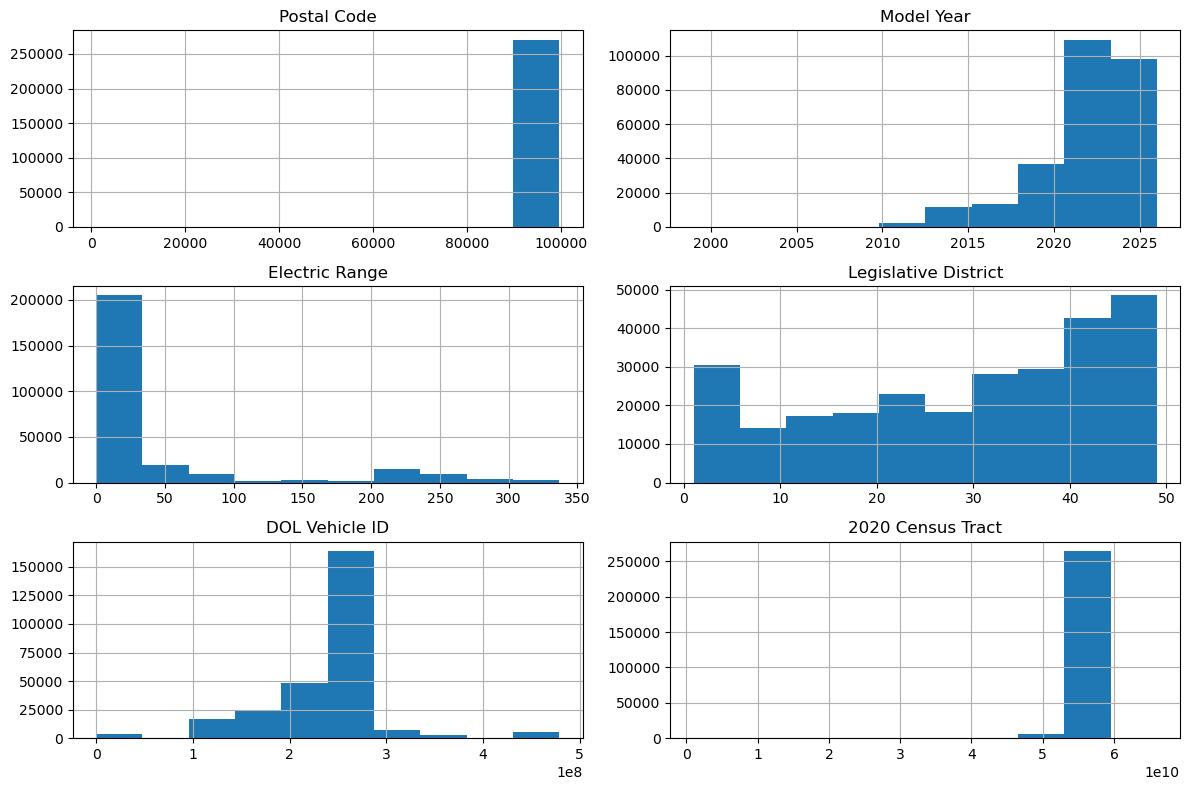

In [6]:
df.hist(figsize=(12, 8))

plt.tight_layout()
plt.show()

In [7]:
df.isna().sum()

VIN (1-10)                                             0
County                                                10
City                                                  10
State                                                  0
Postal Code                                           10
Model Year                                             0
Make                                                   0
Model                                                  0
Electric Vehicle Type                                  0
Clean Alternative Fuel Vehicle (CAFV) Eligibility      0
Electric Range                                         7
Legislative District                                 659
DOL Vehicle ID                                         0
Vehicle Location                                      88
Electric Utility                                      10
2020 Census Tract                                     10
dtype: int64

## Part II - NA Handling

 * **-** Removi 10 linhas com valores *NaNs*, eram informações de registro: Cidade, condado e código postal. apesar não serem essenciais para a análise futura, decidi por remover elas, pois 10 linhas em um *Dataframe* com cerca de 271 mil linhas, não é uma grande perda.

 * **2 -** Removi todas as linhas que não se referiam ao estado de Washington, pois o foco da pesquisa é o estado de Washington, "perdi" cerca de mil linhas com isso, o que novamente não é muito comparado as 270 mil restantes após isso.

 * **3 -** O *Dataset* usa como padrão 0.0 para carros com autonomia não registrada, optei por trocar por *NaNs*, para na análise futura, esses modelos que não tem dados apresentados, puxarem médias para baixo. A maioria dos casos se tratam de carros muito recentes, que não tem esses dados disponíveis para o governo ainda.

 * **4 -** Foram removidas as colunas: localização de veiculo, distrito, vin(idendificador de chassi), código postal, 2020 census tract, estado (Visto que todos são washington) e  *DOL*(Equivalente do detran nos EUA), por serem dados irrelevantes para minha análise ou serem informações repetidas/casadas.

 * **5 -** Criei a coluna idade do veículo, que é medida em anos, sendo o ano do meu projeto (2026) - o ano de fabricação do carro.

 * **6 -** Diversas alterações de nomes nas células de colunas, para deixar os nomes mais curtos e intuitivos; além de valores *NaNs* para carros que não tem alternativa de combustível pesquisada.

 * **7 -** Verificação de outliers pelo metódo de quartis.

---
 ### Q&A

 Q: Porque remover Bonneville?

 * A: Se trata de a compania estatal de Washington, que tinha seu nome vinculado a outros postos de energia, logo não é uma vendedora real em casos como "BONNEVILLE POWER ADMINISTRATION||PUD NO 1 OF COWLITZ COUNTY", além de se tratar da mesma empresa.

 Q: É possível ver outliers! porque não fez nada?

 * A: Ok, usando matemática "bruta", casos como um carro da ford de 1999 ser elétrico podem ser considerados uma *outlier*, mas não é algo mentiroso nem incorreto, apenas algo comum de se ver em um *Dataframe* tão diverso como esse, que possui carros híbridos e elétricos, além de modelos com mais de 20 anos de diferença.

 Q: Porque remover tantas colunas?

 * A: Minha análise tem como objetivo *marketshare*, evolução da tecnologia e aspectos geograficos básicos, logo colunas como número de chassi não importam; e colunas como as cordenadas não convém com o intuito da pesquisa, apesar de serem riquissimas para outros tipos de análise.

 Q: Porque remover as 10 linhas?

 * A: Já que são apenas 10 linhas com valores NaN, perto de 270 mil linhas, removê-las não fará diferença, além disso são informações muito específicas e dificeis de encontrar, logo tranformar essas linhas não vale a pena.

 ---

In [8]:
# Removendo 10 linhas inconsistentes

df = cleaning.drop_incomplete_rows(df)
df.isna().sum()

VIN (1-10)                                             0
County                                                 0
City                                                   0
State                                                  0
Postal Code                                            0
Model Year                                             0
Make                                                   0
Model                                                  0
Electric Vehicle Type                                  0
Clean Alternative Fuel Vehicle (CAFV) Eligibility      0
Electric Range                                         7
Legislative District                                 649
DOL Vehicle ID                                         0
Vehicle Location                                      78
Electric Utility                                       0
2020 Census Tract                                      0
dtype: int64

In [9]:
df.reset_index()

,index,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,0,5YJ3E1EB9J,Kitsap,Bainbridge Island,WA,98110.0,2018,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,215.0,23.0,476462444,POINT (-122.521 47.62732),PUGET SOUND ENERGY INC,5.303509e+10
1,1,JN1AZ0CP2B,Kitsap,Port Orchard,WA,98367.0,2011,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,73.0,26.0,279030461,POINT (-122.70348 47.52028),PUGET SOUND ENERGY INC,5.303509e+10
2,2,JN1AZ0CP8B,King,Bothell,WA,98011.0,2011,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,73.0,1.0,232370001,POINT (-122.20563 47.76144),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303302e+10
3,3,1G1FY6S06L,Yakima,Selah,WA,98942.0,2020,CHEVROLET,BOLT EV,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,259.0,15.0,264646266,POINT (-120.53145 46.65405),PACIFICORP,5.307700e+10
4,4,KNDCM3LD3L,King,Seattle,WA,98133.0,2020,KIA,NIRO,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,26.0,32.0,154002691,POINT (-122.33364 47.73709),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303300e+10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
271098,271108,5YJ3E1EC8P,Snohomish,Woodinville,WA,98077.0,2023,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,1.0,241530824,POINT (-122.07326 47.75425),PUGET SOUND ENERGY INC,5.306105e+10
271099,271109,7FCEHEB2XR,Skagit,Burlington,WA,98233.0,2024,RIVIAN,EDV,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,10.0,283223496,POINT (-122.33029 48.46846),PUGET SOUND ENERGY INC,5.305795e+10
271100,271110,3GPKHZRJ8R,Clark,Vancouver,WA,98682.0,2024,HONDA,PROLOGUE,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,17.0,276399231,POINT (-122.55149 45.69345),BONNEVILLE POWER ADMINISTRATION||PUD NO 1 OF C...,5.301104e+10
271101,271111,1C4JJXN6XP,Pierce,Tacoma,WA,98406.0,2023,JEEP,WRANGLER,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,21.0,28.0,280031559,POINT (-122.52082 47.26887),BONNEVILLE POWER ADMINISTRATION||CITY OF TACOM...,5.305306e+10


In [10]:
# Garantindo que estamos olhando apenas para Washington

df = cleaning.keep_washington(df)
df

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,5YJ3E1EB9J,Kitsap,Bainbridge Island,WA,98110.0,2018,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,215.0,23.0,476462444,POINT (-122.521 47.62732),PUGET SOUND ENERGY INC,5.303509e+10
1,JN1AZ0CP2B,Kitsap,Port Orchard,WA,98367.0,2011,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,73.0,26.0,279030461,POINT (-122.70348 47.52028),PUGET SOUND ENERGY INC,5.303509e+10
2,JN1AZ0CP8B,King,Bothell,WA,98011.0,2011,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,73.0,1.0,232370001,POINT (-122.20563 47.76144),PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),5.303302e+10
3,1G1FY6S06L,Yakima,Selah,WA,98942.0,2020,CHEVROLET,BOLT EV,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,259.0,15.0,264646266,POINT (-120.53145 46.65405),PACIFICORP,5.307700e+10
4,KNDCM3LD3L,King,Seattle,WA,98133.0,2020,KIA,NIRO,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,26.0,32.0,154002691,POINT (-122.33364 47.73709),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303300e+10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
271108,5YJ3E1EC8P,Snohomish,Woodinville,WA,98077.0,2023,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,1.0,241530824,POINT (-122.07326 47.75425),PUGET SOUND ENERGY INC,5.306105e+10
271109,7FCEHEB2XR,Skagit,Burlington,WA,98233.0,2024,RIVIAN,EDV,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,10.0,283223496,POINT (-122.33029 48.46846),PUGET SOUND ENERGY INC,5.305795e+10
271110,3GPKHZRJ8R,Clark,Vancouver,WA,98682.0,2024,HONDA,PROLOGUE,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,17.0,276399231,POINT (-122.55149 45.69345),BONNEVILLE POWER ADMINISTRATION||PUD NO 1 OF C...,5.301104e+10
271111,1C4JJXN6XP,Pierce,Tacoma,WA,98406.0,2023,JEEP,WRANGLER,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,21.0,28.0,280031559,POINT (-122.52082 47.26887),BONNEVILLE POWER ADMINISTRATION||CITY OF TACOM...,5.305306e+10


## Part III - Replacing Rows with 0.0 Autonomy

 Analisando com o *Data Wrangler* os valores de autonomia, percebe-se que muitos carros estão com valores 0, pesquisando mais a fundo, descobri que são veículos mais recentes, e que não tem sua autonomia registrada oficialmente. Além disso colunas como distrito legislativo e a localização em coordenadas também possuem valores nulos ou zerados, mas manterei os NaNs e transformarei os 0s em NaNs, pois essas colunas pouco importam para a análise.

 ---

In [11]:
# Redigindo os valores zero para NaNs

df = cleaning.blank_unresearched_range(df)
df["Electric Range"].isna().sum()

np.int64(170437)

## Part IV - Columns Removal and Handling

Irei remover as colunas de localização de veiculo, distrito, vin(idendificador de chassi), código postal, 2020 census tract, estado(Visto que todos são washington) e *DOL*(Equivalente do detran  em Washington) visto que essa EDA foca mais em mercado e não estatíticas geograficas precisas.

---

In [12]:
# Removendo as colunas citadas acima (cleaning.COLS_TO_DROP)

df = cleaning.drop_unused_columns(df)
df.head()

,County,City,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Electric Utility
0,Kitsap,Bainbridge Island,2018,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,215.0,PUGET SOUND ENERGY INC
1,Kitsap,Port Orchard,2011,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,73.0,PUGET SOUND ENERGY INC
2,King,Bothell,2011,NISSAN,LEAF,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,73.0,PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA)
3,Yakima,Selah,2020,CHEVROLET,BOLT EV,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,259.0,PACIFICORP
4,King,Seattle,2020,KIA,NIRO,Plug-in Hybrid Electric Vehicle (PHEV),Not eligible due to low battery range,26.0,CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA)


In [13]:
# Irei trocar os títulos das celulas da coluna Clean alternative fuel
# para serem mais curtos e intuitivos, e o nome da coluna para algo mais curto

df = cleaning.shorten_cafv_status(df)
df

,County,City,Model Year,Make,Model,Electric Vehicle Type,CAFV Status,Electric Range,Electric Utility
0,Kitsap,Bainbridge Island,2018,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Eligible,215.0,PUGET SOUND ENERGY INC
1,Kitsap,Port Orchard,2011,NISSAN,LEAF,Battery Electric Vehicle (BEV),Eligible,73.0,PUGET SOUND ENERGY INC
2,King,Bothell,2011,NISSAN,LEAF,Battery Electric Vehicle (BEV),Eligible,73.0,PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA)
3,Yakima,Selah,2020,CHEVROLET,BOLT EV,Battery Electric Vehicle (BEV),Eligible,259.0,PACIFICORP
4,King,Seattle,2020,KIA,NIRO,Plug-in Hybrid Electric Vehicle (PHEV),Not Eligible (Low Range),26.0,CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA)
...,...,...,...,...,...,...,...,...,...
271108,Snohomish,Woodinville,2023,TESLA,MODEL 3,Battery Electric Vehicle (BEV),NaN,NaN,PUGET SOUND ENERGY INC
271109,Skagit,Burlington,2024,RIVIAN,EDV,Battery Electric Vehicle (BEV),NaN,NaN,PUGET SOUND ENERGY INC
271110,Clark,Vancouver,2024,HONDA,PROLOGUE,Battery Electric Vehicle (BEV),NaN,NaN,BONNEVILLE POWER ADMINISTRATION||PUD NO 1 OF C...
271111,Pierce,Tacoma,2023,JEEP,WRANGLER,Plug-in Hybrid Electric Vehicle (PHEV),Not Eligible (Low Range),21.0,BONNEVILLE POWER ADMINISTRATION||CITY OF TACOM...


In [14]:
# Também achei conveniente diminuir o tamanho das siglas na coluna de tipo

df = cleaning.abbreviate_vehicle_type(df)
df

,County,City,Model Year,Make,Model,Electric Vehicle Type,CAFV Status,Electric Range,Electric Utility
0,Kitsap,Bainbridge Island,2018,TESLA,MODEL 3,BEV,Eligible,215.0,PUGET SOUND ENERGY INC
1,Kitsap,Port Orchard,2011,NISSAN,LEAF,BEV,Eligible,73.0,PUGET SOUND ENERGY INC
2,King,Bothell,2011,NISSAN,LEAF,BEV,Eligible,73.0,PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA)
3,Yakima,Selah,2020,CHEVROLET,BOLT EV,BEV,Eligible,259.0,PACIFICORP
4,King,Seattle,2020,KIA,NIRO,PHEV,Not Eligible (Low Range),26.0,CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA)
...,...,...,...,...,...,...,...,...,...
271108,Snohomish,Woodinville,2023,TESLA,MODEL 3,BEV,NaN,NaN,PUGET SOUND ENERGY INC
271109,Skagit,Burlington,2024,RIVIAN,EDV,BEV,NaN,NaN,PUGET SOUND ENERGY INC
271110,Clark,Vancouver,2024,HONDA,PROLOGUE,BEV,NaN,NaN,BONNEVILLE POWER ADMINISTRATION||PUD NO 1 OF C...
271111,Pierce,Tacoma,2023,JEEP,WRANGLER,PHEV,Not Eligible (Low Range),21.0,BONNEVILLE POWER ADMINISTRATION||CITY OF TACOM...


In [15]:
# Verificando se as alterações foram bem sucedidas

df.columns

Index(['County', 'City', 'Model Year', 'Make', 'Model',
       'Electric Vehicle Type', 'CAFV Status', 'Electric Range',
       'Electric Utility'],
      dtype='str')

In [16]:
# Adicionando uma coluna com a idade do veículo em anos,
# medida contra o ano do snapshot (cleaning.SNAPSHOT_YEAR)

df = cleaning.add_vehicle_age(df)
df

,County,City,Model Year,Make,Model,Electric Vehicle Type,CAFV Status,Electric Range,Electric Utility,Vehicle Age
0,Kitsap,Bainbridge Island,2018,TESLA,MODEL 3,BEV,Eligible,215.0,PUGET SOUND ENERGY INC,8
1,Kitsap,Port Orchard,2011,NISSAN,LEAF,BEV,Eligible,73.0,PUGET SOUND ENERGY INC,15
2,King,Bothell,2011,NISSAN,LEAF,BEV,Eligible,73.0,PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA),15
3,Yakima,Selah,2020,CHEVROLET,BOLT EV,BEV,Eligible,259.0,PACIFICORP,6
4,King,Seattle,2020,KIA,NIRO,PHEV,Not Eligible (Low Range),26.0,CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),6
...,...,...,...,...,...,...,...,...,...,...
271108,Snohomish,Woodinville,2023,TESLA,MODEL 3,BEV,NaN,NaN,PUGET SOUND ENERGY INC,3
271109,Skagit,Burlington,2024,RIVIAN,EDV,BEV,NaN,NaN,PUGET SOUND ENERGY INC,2
271110,Clark,Vancouver,2024,HONDA,PROLOGUE,BEV,NaN,NaN,BONNEVILLE POWER ADMINISTRATION||PUD NO 1 OF C...,2
271111,Pierce,Tacoma,2023,JEEP,WRANGLER,PHEV,Not Eligible (Low Range),21.0,BONNEVILLE POWER ADMINISTRATION||CITY OF TACOM...,3


In [17]:
# Verificando os nomes dos itens da coluna de fornecedores

df["Electric Utility"].unique()

<StringArray>
[                                                                                          'PUGET SOUND ENERGY INC',
                                                                    'PUGET SOUND ENERGY INC||CITY OF TACOMA - (WA)',
                                                                                                       'PACIFICORP',
                                                                     'CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA)',
                                                                                                      'AVISTA CORP',
                                                                                        'PUD NO 1 OF CHELAN COUNTY',
                                                                                         'PUD NO 2 OF GRANT COUNTY',
                                                                                    'MODERN ELECTRIC WATER COMPANY',
                                                  

In [18]:
# Limpando os nomes dos fornecedores de energia, removendo INC, WA,
# símbolos e nomes desnecessáriamente longos

df = cleaning.simplify_utility(df)
df["Electric Utility"].unique()

array(['Puget Sound Energy', 'Pacificorp', 'City Of Seattle',
       'Avista Corp', 'Pud No 1 Of Chelan County',
       'Pud No 2 Of Grant County', 'Modern Electric Water Company',
       'Pud No 1 Of Douglas County', 'No Known Electric Utility Service',
       'Pud No 1 Of Pend Oreille County',
       'Bonneville Power Administration', 'City Of Tacoma',
       'Portland General Electric Co', 'City Of Chewelah',
       'City Of Blaine', 'City Of Cheney', 'Pud No 1 Of Okanogan County',
       'Okanogan County Elec Coop,', 'Pud No 1 Of Whatcom County',
       'City Of Sumas'], dtype=object)

## Part V - Adding a Vehicle Age Column

In [19]:
# A idade já sai como INT de cleaning.add_vehicle_age, pois anos são
# medidas inteiras

df.info()

<class 'pandas.DataFrame'>
Index: 270454 entries, 0 to 271112
Data columns (total 10 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   County                 270454 non-null  str    
 1   City                   270454 non-null  str    
 2   Model Year             270454 non-null  int64  
 3   Make                   270454 non-null  str    
 4   Model                  270454 non-null  str    
 5   Electric Vehicle Type  270454 non-null  str    
 6   CAFV Status            100024 non-null  str    
 7   Electric Range         100017 non-null  float64
 8   Electric Utility       270454 non-null  object 
 9   Vehicle Age            270454 non-null  int64  
dtypes: float64(1), int64(2), object(1), str(6)
memory usage: 22.7+ MB


## Part VI - Outliers Check and Handling

 Para verificar a existência de *outliers* eu decidi identificar por meio do método de quartis, que se trata de encontrar os valores mais baixos(25% mais baixos) e mais altos(75% mais altos) e compará-los em relação a média das informações. 

 ---

## *Outliers* mas nem tanto...

 Como dito anteriormente, ao pesquisar por *outliers* na coluna de idade do veículo, se encontra valores como o do Ford Ranger, que foi lançado em 1999, porém não removi ele e outras *outliers*, visto que não é algo mentiroso, apenas algo comum em um *dataset* que abrange tantos anos.

 ---

In [20]:
# Verificando outliers nas colunas de idade, autonomia e ano de fabricação


utils.outliers_quartile(df, "Vehicle Age")

,County,City,Model Year,Make,Model,Electric Vehicle Type,CAFV Status,Electric Range,Electric Utility,Vehicle Age
1,Kitsap,Port Orchard,2011,NISSAN,LEAF,BEV,Eligible,73.0,Puget Sound Energy,15
2,King,Bothell,2011,NISSAN,LEAF,BEV,Eligible,73.0,Puget Sound Energy,15
6,King,Seattle,2016,AUDI,A3,PHEV,Not Eligible (Low Range),16.0,City Of Seattle,10
12,Thurston,Olympia,2013,NISSAN,LEAF,BEV,Eligible,75.0,Puget Sound Energy,13
14,Yakima,Yakima,2016,TESLA,MODEL X,BEV,Eligible,200.0,Pacificorp,10
...,...,...,...,...,...,...,...,...,...,...
271017,Clallam,Port Angeles,2013,TESLA,MODEL S,BEV,Eligible,208.0,Bonneville Power Administration,13
271056,Snohomish,Arlington,2015,NISSAN,LEAF,BEV,Eligible,84.0,Bonneville Power Administration,11
271059,Snohomish,Snohomish,2015,FIAT,500,BEV,Eligible,87.0,Puget Sound Energy,11
271071,Whatcom,Bellingham,2015,TESLA,MODEL S,BEV,Eligible,208.0,Puget Sound Energy,11


In [21]:
# Devido a muitos valores NaNs, foi retornado um Dataframe vazio
# Por segurança irei verificar de outra forma abaixo

utils.outliers_quartile(df, "Electric Range")

,County,City,Model Year,Make,Model,Electric Vehicle Type,CAFV Status,Electric Range,Electric Utility,Vehicle Age


In [22]:
# Após uma análise mais manual, nada de incomum foi encontrado

print(df["Electric Range"].quantile(0.25))
print(df["Electric Range"].quantile(0.75))
print(df["Electric Range"].max())

30.0
215.0
337.0


In [23]:
# Verificando os BEVs de forma separada

bevs = df[df["Electric Vehicle Type"] == "BEV"]

print(bevs["Electric Range"].quantile(0.25))
print(bevs["Electric Range"].quantile(0.75))
print(bevs["Electric Range"].max())

150.0
238.0
337.0


In [24]:
# Sem outliers em BEVs!

utils.outliers_quartile(bevs, "Electric Range")

,County,City,Model Year,Make,Model,Electric Vehicle Type,CAFV Status,Electric Range,Electric Utility,Vehicle Age


In [25]:
# Checando os PHEVs de forma avulsa agora

phevs = df[df["Electric Vehicle Type"] == "PHEV"]

print(phevs["Electric Range"].quantile(0.25))
print(phevs["Electric Range"].quantile(0.75))
print(phevs["Electric Range"].max())

21.0
38.0
153.0


## Mais falsas *outliers*

 Esses dados de são tão reais quanto o Ford Ranger, eles foram taxados como *outliers* pois a diferença tecnológica entre certos carros é enorme, Mas não existem dados mentiroso como um carro com 50.000 km de autonomia.

 ---

In [26]:
# Sem outliers em PHEVs também!

utils.outliers_quartile(phevs, "Electric Range")

,County,City,Model Year,Make,Model,Electric Vehicle Type,CAFV Status,Electric Range,Electric Utility,Vehicle Age
30,Thurston,Olympia,2018,BMW,I3,PHEV,Eligible,97.0,Puget Sound Energy,8
94,King,Renton,2014,BMW,I3,PHEV,Eligible,72.0,Puget Sound Energy,12
206,King,Seattle,2019,BMW,I3,PHEV,Eligible,126.0,City Of Seattle,7
220,Snohomish,Edmonds,2017,BMW,I3,PHEV,Eligible,97.0,Puget Sound Energy,9
295,Kitsap,Port Orchard,2017,BMW,I3,PHEV,Eligible,97.0,Puget Sound Energy,9
...,...,...,...,...,...,...,...,...,...,...
268849,Thurston,Olympia,2020,BMW,I3,PHEV,Eligible,126.0,Puget Sound Energy,6
269887,Island,Coupeville,2014,BMW,I3,PHEV,Eligible,72.0,Puget Sound Energy,12
270523,Whatcom,Bellingham,2019,BMW,I3,PHEV,Eligible,126.0,Puget Sound Energy,7
271075,King,Woodinville,2019,BMW,I3,PHEV,Eligible,126.0,Puget Sound Energy,7


In [27]:
# última coluna ano de fabricação
# nada anormal, visto que é uma informação "casada" com a de idade do carro

utils.outliers_quartile(df, "Model Year")

,County,City,Model Year,Make,Model,Electric Vehicle Type,CAFV Status,Electric Range,Electric Utility,Vehicle Age
1,Kitsap,Port Orchard,2011,NISSAN,LEAF,BEV,Eligible,73.0,Puget Sound Energy,15
2,King,Bothell,2011,NISSAN,LEAF,BEV,Eligible,73.0,Puget Sound Energy,15
6,King,Seattle,2016,AUDI,A3,PHEV,Not Eligible (Low Range),16.0,City Of Seattle,10
12,Thurston,Olympia,2013,NISSAN,LEAF,BEV,Eligible,75.0,Puget Sound Energy,13
14,Yakima,Yakima,2016,TESLA,MODEL X,BEV,Eligible,200.0,Pacificorp,10
...,...,...,...,...,...,...,...,...,...,...
271017,Clallam,Port Angeles,2013,TESLA,MODEL S,BEV,Eligible,208.0,Bonneville Power Administration,13
271056,Snohomish,Arlington,2015,NISSAN,LEAF,BEV,Eligible,84.0,Bonneville Power Administration,11
271059,Snohomish,Snohomish,2015,FIAT,500,BEV,Eligible,87.0,Puget Sound Energy,11
271071,Whatcom,Bellingham,2015,TESLA,MODEL S,BEV,Eligible,208.0,Puget Sound Energy,11


## Parte VII - Teste de Sanidade e Salvando o Arquivo Limpo
 A culminância da limpeza, talvez a parte mais simples desse *notebook*, mas a mais recompensadora; aqui foram executados testes de lógica e ajustes finais antes da exportação do arquivo para o formato CSV.

 ---

In [28]:
# Teste de lógica

df.describe()

,Model Year,Electric Range,Vehicle Age
count,270454.000000,100017.000000,270454.000000
mean,2021.995929,107.840707,4.004071
std,3.057503,97.173657,3.057503
min,1999.000000,1.000000,0.000000
25%,2021.000000,30.000000,2.000000
50%,2023.000000,48.000000,3.000000
75%,2024.000000,215.000000,5.000000
max,2026.000000,337.000000,27.000000


In [29]:
# Por segurança, irei resetar o index novamente

df.reset_index(drop=True)

,County,City,Model Year,Make,Model,Electric Vehicle Type,CAFV Status,Electric Range,Electric Utility,Vehicle Age
0,Kitsap,Bainbridge Island,2018,TESLA,MODEL 3,BEV,Eligible,215.0,Puget Sound Energy,8
1,Kitsap,Port Orchard,2011,NISSAN,LEAF,BEV,Eligible,73.0,Puget Sound Energy,15
2,King,Bothell,2011,NISSAN,LEAF,BEV,Eligible,73.0,Puget Sound Energy,15
3,Yakima,Selah,2020,CHEVROLET,BOLT EV,BEV,Eligible,259.0,Pacificorp,6
4,King,Seattle,2020,KIA,NIRO,PHEV,Not Eligible (Low Range),26.0,City Of Seattle,6
...,...,...,...,...,...,...,...,...,...,...
270449,Snohomish,Woodinville,2023,TESLA,MODEL 3,BEV,NaN,NaN,Puget Sound Energy,3
270450,Skagit,Burlington,2024,RIVIAN,EDV,BEV,NaN,NaN,Puget Sound Energy,2
270451,Clark,Vancouver,2024,HONDA,PROLOGUE,BEV,NaN,NaN,Bonneville Power Administration,2
270452,Pierce,Tacoma,2023,JEEP,WRANGLER,PHEV,Not Eligible (Low Range),21.0,Bonneville Power Administration,3


In [30]:
# Mais um último teste

df

,County,City,Model Year,Make,Model,Electric Vehicle Type,CAFV Status,Electric Range,Electric Utility,Vehicle Age
0,Kitsap,Bainbridge Island,2018,TESLA,MODEL 3,BEV,Eligible,215.0,Puget Sound Energy,8
1,Kitsap,Port Orchard,2011,NISSAN,LEAF,BEV,Eligible,73.0,Puget Sound Energy,15
2,King,Bothell,2011,NISSAN,LEAF,BEV,Eligible,73.0,Puget Sound Energy,15
3,Yakima,Selah,2020,CHEVROLET,BOLT EV,BEV,Eligible,259.0,Pacificorp,6
4,King,Seattle,2020,KIA,NIRO,PHEV,Not Eligible (Low Range),26.0,City Of Seattle,6
...,...,...,...,...,...,...,...,...,...,...
271108,Snohomish,Woodinville,2023,TESLA,MODEL 3,BEV,NaN,NaN,Puget Sound Energy,3
271109,Skagit,Burlington,2024,RIVIAN,EDV,BEV,NaN,NaN,Puget Sound Energy,2
271110,Clark,Vancouver,2024,HONDA,PROLOGUE,BEV,NaN,NaN,Bonneville Power Administration,2
271111,Pierce,Tacoma,2023,JEEP,WRANGLER,PHEV,Not Eligible (Low Range),21.0,Bonneville Power Administration,3


In [31]:
# Exportando o data frame limpo

df.to_csv("data/processed/ev_dados_washington_limpo.csv", index=False)

# Fim da limpeza!

---